# VQA Task A1 — ViT + PhoBERT + Co-attention + LSTM Decoder

## Cell 1 — Mount Google Drive & Giai nen Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP_PATH    = '/content/drive/MyDrive/vqa-animal-dataset.zip'
EXTRACT_PATH = '/content/vqa-animal-dataset'

if not os.path.exists(EXTRACT_PATH):
    print("Dang giai nen...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print("Hoan thanh.")
else:
    print("Dataset da ton tai, bo qua giai nen.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset da ton tai, bo qua giai nen.


## Cell 2 — Install & Import

In [ ]:
# Cai dat thu vien bo sung
!pip install -q bert-score rouge-score underthesea

import os, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms

from transformers import ViTModel, AutoModel, AutoTokenizer

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score

nltk.download('wordnet', quiet=True)
nltk.download('punkt',   quiet=True)

print("Import hoan thanh.")

Import hoan thanh.


## Cell 3 — Config

In [ ]:
CFG = {
    # Duong dan
    'data_root':       '/content/vqa-animal-dataset',
    'train_csv':       '/content/vqa-animal-dataset/train.csv',
    'val_csv':         '/content/vqa-animal-dataset/val.csv',
    'test_csv':        '/content/vqa-animal-dataset/test.csv',
    'ckpt_dir':        '/content/drive/MyDrive/vqa_checkpoints',

    # Kien truc mo hinh
    'vit_model':       'google/vit-base-patch16-224',
    'phobert_model':   'vinai/phobert-base',
    'hidden_dim':      512,
    'word_embed_dim':  256,
    'lstm_layers':     2,
    'num_heads':       8,
    'q_max_len':       64,

    # Huan luyen
    'lr':              2e-4,   # tang theo batch (64->256 = 4x, dung 2x cho an toan)
    'epochs':          30,
    'batch_size':      256,
    'max_decode_len':  25,
    'teacher_forcing': 1.0,
    'patience':        7,
    'seed':            42,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

torch.backends.cudnn.benchmark = True  # toi uu kernel cho fixed input size

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])
os.makedirs(CFG['ckpt_dir'], exist_ok=True)

Device: cuda


## Cell 4 — Dataset & Vocab

In [ ]:
# ---- Xay dung vocab tu tap train ----
def build_vocab(df):
    PAD, SOS, EOS, UNK = '<PAD>', '<SOS>', '<EOS>', '<UNK>'
    tokens = set()
    for ans in df['answer'].dropna():
        tokens.update(str(ans).lower().split())
    vocab = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
    for t in sorted(tokens):
        if t not in vocab:
            vocab[t] = len(vocab)
    return vocab

def encode_answer(ans, vocab, max_len):
    SOS, EOS, UNK = vocab['<SOS>'], vocab['<EOS>'], vocab['<UNK>']
    ids = [SOS]
    for w in str(ans).lower().split()[:max_len - 2]:
        ids.append(vocab.get(w, UNK))
    ids.append(EOS)
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

train_df = pd.read_csv(CFG['train_csv'])
val_df   = pd.read_csv(CFG['val_csv'])
test_df  = pd.read_csv(CFG['test_csv'])

VOCAB      = build_vocab(train_df)
INV_VOCAB  = {v: k for k, v in VOCAB.items()}
VOCAB_SIZE = len(VOCAB)
PAD_IDX    = VOCAB['<PAD>']
SOS_IDX    = VOCAB['<SOS>']
EOS_IDX    = VOCAB['<EOS>']
print(f"Vocab size: {VOCAB_SIZE}")

# ---- Helper: id sequence -> tokens ----
DROP_TOKENS = ('<PAD>', '<SOS>', '<UNK>')

def ids_to_tokens(ids):
    """Cat tai <EOS> va bo special tokens."""
    out = []
    for i in ids:
        tok = INV_VOCAB.get(int(i), '')
        if tok == '<EOS>':
            break
        if tok not in DROP_TOKENS:
            out.append(tok)
    return out

# ---- Word segmentation cho PhoBERT ----
from underthesea import word_tokenize as _vi_word_tokenize

def segment_vi(text):
    """Tach tu tieng Viet cho PhoBERT tokenizer."""
    return _vi_word_tokenize(str(text), format='text')

# ---- Preprocessing anh (chi resize + normalize) ----
IMG_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ---- Tokenizer PhoBERT ----
PHOBERT_TOKENIZER = AutoTokenizer.from_pretrained(CFG['phobert_model'])

# ---- VQA Dataset ----
class VQADataset(Dataset):
    """
    image_path trong CSV co dang 'animal_dataset/animals/animals/{label}/{file}.jpg'
    nhung anh thuc te nam o '{data_root}/{split}/{label}/{file}.jpg'.
    Do do path duoc tai tao tu split + label + basename.

    Cau hoi duoc tach tu (underthesea) ngay trong __init__ va cache theo unique
    question (du lieu thuong co rat nhieu cau hoi trung lap).
    """
    def __init__(self, df, vocab, data_root, split, max_decode_len, q_max_len):
        self.df             = df.reset_index(drop=True)
        self.vocab          = vocab
        self.data_root      = data_root
        self.split          = split
        self.max_decode_len = max_decode_len
        self.q_max_len      = q_max_len

        # Tach tu cau hoi va cache theo noi dung cau hoi
        questions = self.df['question'].astype(str).tolist()
        unique_qs = list({q for q in questions})
        print(f"  Segmenting questions cho split '{split}' "
              f"({len(questions)} mau, {len(unique_qs)} unique)...")
        seg_cache = {q: segment_vi(q) for q in unique_qs}
        self.questions_seg = [seg_cache[q] for q in questions]

    def __len__(self):
        return len(self.df)

    def resolve_image_path(self, row):
        basename = os.path.basename(str(row['image_path']))
        return os.path.join(self.data_root, self.split, str(row['label']), basename)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load anh
        img_path = self.resolve_image_path(row)
        if not os.path.exists(img_path):
            raise FileNotFoundError(
                f"Khong tim thay anh: {img_path} "
                f"(split={self.split}, label={row['label']}, csv_path={row['image_path']})"
            )
        img = Image.open(img_path).convert('RGB')
        img_tensor = IMG_TRANSFORM(img)

        # Tokenize cau hoi
        enc = PHOBERT_TOKENIZER(
            self.questions_seg[idx],
            max_length=self.q_max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        q_ids  = enc['input_ids'].squeeze(0)
        q_mask = enc['attention_mask'].squeeze(0)

        # Encode cau tra loi
        ans_ids = torch.tensor(
            encode_answer(row['answer'], self.vocab, self.max_decode_len),
            dtype=torch.long
        )
        return img_tensor, q_ids, q_mask, ans_ids

train_ds = VQADataset(train_df, VOCAB, CFG['data_root'], 'train', CFG['max_decode_len'], CFG['q_max_len'])
val_ds   = VQADataset(val_df,   VOCAB, CFG['data_root'], 'val',   CFG['max_decode_len'], CFG['q_max_len'])
test_ds  = VQADataset(test_df,  VOCAB, CFG['data_root'], 'test',  CFG['max_decode_len'], CFG['q_max_len'])

# Kiem tra nhanh path anh
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    _ = ds[0]
print("[OK] Path resolver hoat dong dung tren ca 3 split.")

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Vocab size: 1480


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Segmenting questions cho split 'train' (233280 mau, 2835 unique)...
  Segmenting questions cho split 'val' (3240 mau, 35 unique)...
  Segmenting questions cho split 'test' (3240 mau, 35 unique)...
[OK] Path resolver hoat dong dung tren ca 3 split.
Train: 233280 | Val: 3240 | Test: 3240


## Cell 5 — Model

In [ ]:
# ---- Image Encoder (ViT-Base/16, frozen) ----
class ImageEncoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.vit = ViTModel.from_pretrained(model_name)
        self.vit.requires_grad_(False)
        self.vit.eval()
        self.hidden_size = self.vit.config.hidden_size

    def train(self, mode=True):
        # Giu encoder frozen o eval mode
        super().train(mode)
        self.vit.eval()
        return self

    def forward(self, pixel_values):
        # Tra ve patch tokens
        with torch.no_grad():
            out = self.vit(pixel_values=pixel_values)
        return out.last_hidden_state


# ---- Text Encoder (PhoBERT-base, frozen) ----
class TextEncoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.bert.requires_grad_(False)
        self.bert.eval()
        self.hidden_size = self.bert.config.hidden_size

    def train(self, mode=True):
        # Giu encoder frozen o eval mode
        super().train(mode)
        self.bert.eval()
        return self

    def forward(self, input_ids, attention_mask):
        # Tra ve token embeddings
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state


# ---- Co-Attention Fusion ----
class CoAttention(nn.Module):
    """Bidirectional cross-attention giua anh va van ban."""
    def __init__(self, embed_dim, num_heads, hidden_dim):
        super().__init__()
        self.img2txt = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.txt2img = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.proj    = nn.Linear(embed_dim * 2, hidden_dim)
        self.norm    = nn.LayerNorm(hidden_dim)

    def forward(self, img_feat, txt_feat, txt_key_padding_mask=None):
        # key_padding_mask=True tai vi tri padding
        kp_mask = ((1 - txt_key_padding_mask).bool()
                   if txt_key_padding_mask is not None else None)

        # Anh attend vao text
        ctx_img, _ = self.img2txt(img_feat, txt_feat, txt_feat, key_padding_mask=kp_mask)
        # Text attend vao anh
        ctx_txt, _ = self.txt2img(txt_feat, img_feat, img_feat)

        # Pooling dac trung anh va text
        v_img = ctx_img.mean(dim=1)
        if txt_key_padding_mask is not None:
            m = txt_key_padding_mask.unsqueeze(-1).float()
            v_txt = (ctx_txt * m).sum(dim=1) / m.sum(dim=1).clamp(min=1)
        else:
            v_txt = ctx_txt.mean(dim=1)

        fused = torch.cat([v_img, v_txt], dim=-1)
        return self.norm(F.relu(self.proj(fused)))


# ---- LSTM Decoder ----
class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, word_embed_dim, lstm_layers):
        super().__init__()
        self.embed      = nn.Embedding(vocab_size, word_embed_dim, padding_idx=PAD_IDX)
        self.lstm       = nn.LSTM(word_embed_dim + hidden_dim, hidden_dim,
                                  num_layers=lstm_layers, batch_first=True)
        self.fc_out     = nn.Linear(hidden_dim, vocab_size)
        self.init_h     = nn.Linear(hidden_dim, hidden_dim * lstm_layers)
        self.init_c     = nn.Linear(hidden_dim, hidden_dim * lstm_layers)
        self.n_layers   = lstm_layers
        self.hidden_dim = hidden_dim

    def _init_hidden(self, fused):
        B = fused.size(0)
        h = self.init_h(fused).view(B, self.n_layers, self.hidden_dim)
        c = self.init_c(fused).view(B, self.n_layers, self.hidden_dim)
        return h.permute(1, 0, 2).contiguous(), c.permute(1, 0, 2).contiguous()

    def forward(self, fused, target_ids, teacher_forcing_ratio=0.5):
        """Training mode: tra ve logits [B, T-1, vocab_size]."""
        T  = target_ids.size(1)
        hx = self._init_hidden(fused)
        logits = []
        inp = target_ids[:, 0]

        for t in range(1, T):
            emb = self.embed(inp).unsqueeze(1)
            ctx = fused.unsqueeze(1)
            x   = torch.cat([emb, ctx], dim=-1)
            out, hx = self.lstm(x, hx)
            log = self.fc_out(out.squeeze(1))
            logits.append(log)

            if random.random() < teacher_forcing_ratio:
                inp = target_ids[:, t]
            else:
                inp = log.argmax(dim=-1)

        return torch.stack(logits, dim=1)

    def inference(self, fused, max_len, sos_idx, eos_idx):
        """Greedy decode den <EOS>."""
        B  = fused.size(0)
        hx = self._init_hidden(fused)
        inp = torch.full((B,), sos_idx, dtype=torch.long, device=fused.device)
        finished = torch.zeros(B, dtype=torch.bool, device=fused.device)
        seqs = []

        for _ in range(max_len):
            emb = self.embed(inp).unsqueeze(1)
            ctx = fused.unsqueeze(1)
            x   = torch.cat([emb, ctx], dim=-1)
            out, hx = self.lstm(x, hx)
            log = self.fc_out(out.squeeze(1))
            pred = log.argmax(dim=-1)
            seqs.append(pred)
            finished |= (pred == eos_idx)
            if finished.all():
                break
            inp = pred

        return torch.stack(seqs, dim=1)


# ---- VQA Model ----
class VQAModel(nn.Module):
    def __init__(self, cfg, vocab_size):
        super().__init__()
        self.img_enc = ImageEncoder(cfg['vit_model'])
        self.txt_enc = TextEncoder(cfg['phobert_model'])

        # Khoi tao fusion va decoder
        assert self.img_enc.hidden_size == self.txt_enc.hidden_size, \
            "ViT va PhoBERT can cung hidden_size cho co-attention"
        embed_dim = self.img_enc.hidden_size

        self.coattn  = CoAttention(embed_dim, cfg['num_heads'], cfg['hidden_dim'])
        self.decoder = LSTMDecoder(vocab_size, cfg['hidden_dim'],
                                   cfg['word_embed_dim'], cfg['lstm_layers'])

    def forward(self, images, q_ids, q_mask, ans_ids=None, tf_ratio=0.5):
        img_feat = self.img_enc(images)
        txt_feat = self.txt_enc(q_ids, q_mask)
        fused    = self.coattn(img_feat, txt_feat, q_mask)

        if ans_ids is not None:
            return self.decoder(fused, ans_ids, tf_ratio)
        return self.decoder.inference(fused, CFG['max_decode_len'], SOS_IDX, EOS_IDX)


model = VQAModel(CFG, VOCAB_SIZE).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 12,428,232


## Cell 6 — Training Loop

In [ ]:
optimizer = AdamW(
    list(model.coattn.parameters()) + list(model.decoder.parameters()),
    lr=CFG['lr'], weight_decay=1e-2
)
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def compute_bleu4(model, loader):
    model.eval()
    refs, hyps = [], []
    with torch.no_grad():
        for imgs, q_ids, q_mask, ans_ids in loader:
            imgs, q_ids, q_mask = imgs.to(DEVICE), q_ids.to(DEVICE), q_mask.to(DEVICE)
            pred_ids = model(imgs, q_ids, q_mask)
            for b in range(ans_ids.size(0)):
                refs.append([ids_to_tokens(ans_ids[b][1:])])
                hyps.append(ids_to_tokens(pred_ids[b]))
    sf = SmoothingFunction().method1
    return corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=sf)


history = {'train_loss': [], 'val_loss': [], 'val_bleu4': []}
best_bleu4   = -float('inf')
patience_cnt = 0

for epoch in range(1, CFG['epochs'] + 1):
    # --- Train ---
    model.train()
    total_loss = 0.0
    for imgs, q_ids, q_mask, ans_ids in tqdm(train_loader, desc=f"Epoch {epoch} train"):
        imgs, q_ids, q_mask, ans_ids = (
            imgs.to(DEVICE), q_ids.to(DEVICE),
            q_mask.to(DEVICE), ans_ids.to(DEVICE)
        )
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(imgs, q_ids, q_mask, ans_ids, CFG['teacher_forcing'])
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                ans_ids[:, 1:].reshape(-1)
            )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # --- Validation loss ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, q_ids, q_mask, ans_ids in val_loader:
            imgs, q_ids, q_mask, ans_ids = (
                imgs.to(DEVICE), q_ids.to(DEVICE),
                q_mask.to(DEVICE), ans_ids.to(DEVICE)
            )
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                logits = model(imgs, q_ids, q_mask, ans_ids, 1.0)
                loss = criterion(
                    logits.reshape(-1, VOCAB_SIZE),
                    ans_ids[:, 1:].reshape(-1)
                )
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    # --- Val BLEU-4 ---
    val_bleu4 = compute_bleu4(model, val_loader)
    scheduler.step()

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_bleu4'].append(val_bleu4)

    print(f"[Epoch {epoch:02d}] train_loss={avg_train_loss:.4f} "
          f"val_loss={avg_val_loss:.4f} val_BLEU4={val_bleu4:.4f}")

    # --- Luu checkpoint tot nhat ---
    if val_bleu4 > best_bleu4:
        best_bleu4   = val_bleu4
        patience_cnt = 0
        ckpt_path = os.path.join(CFG['ckpt_dir'], 'best_model_a1.pt')
        trainable_state = {k: v for k, v in model.state_dict().items()
                           if k.startswith(('coattn.', 'decoder.'))}
        torch.save({
            'epoch':      epoch,
            'model':      trainable_state,
            'optimizer':  optimizer.state_dict(),
            'best_bleu4': best_bleu4,
            'vocab':      VOCAB,
            'cfg':        CFG,
        }, ckpt_path)
        print(f"  => Luu checkpoint tai epoch {epoch} (BLEU4={best_bleu4:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= CFG['patience']:
            print(f"Early stopping tai epoch {epoch}.")
            break

print("Huan luyen hoan thanh.")

Epoch 1 train: 100%|██████████| 912/912 [09:51<00:00,  1.54it/s]


[Epoch 01] train_loss=1.9601 val_loss=0.7104 val_BLEU4=0.1638
  => Luu checkpoint tai epoch 1 (BLEU4=0.1638)


Epoch 2 train: 100%|██████████| 912/912 [09:30<00:00,  1.60it/s]


[Epoch 02] train_loss=0.6724 val_loss=0.5326 val_BLEU4=0.2017
  => Luu checkpoint tai epoch 2 (BLEU4=0.2017)


Epoch 3 train: 100%|██████████| 912/912 [09:46<00:00,  1.56it/s]


...

[Epoch 07] train_loss=0.1781 val_loss=0.8149 val_BLEU4=0.1847


Epoch 8 train: 100%|██████████| 912/912 [09:42<00:00,  1.57it/s]


[Epoch 08] train_loss=0.1493 val_loss=0.8605 val_BLEU4=0.1825


Epoch 9 train: 100%|██████████| 912/912 [09:30<00:00,  1.60it/s]


[Epoch 09] train_loss=0.1293 val_loss=0.9028 val_BLEU4=0.1870
Early stopping tai epoch 9.
Huan luyen hoan thanh.


## Cell 7 — Evaluation tren Test Set

In [ ]:
# Load best checkpoint
ckpt = torch.load(os.path.join(CFG['ckpt_dir'], 'best_model_a1.pt'), map_location=DEVICE)
model.load_state_dict(ckpt['model'], strict=False)
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (BLEU4={ckpt['best_bleu4']:.4f})")

# ---- Thu thap ket qua tren test set ----
all_refs, all_hyps = [], []
all_ref_str, all_hyp_str = [], []

with torch.no_grad():
    for imgs, q_ids, q_mask, ans_ids in tqdm(test_loader, desc='Evaluating'):
        imgs, q_ids, q_mask = imgs.to(DEVICE), q_ids.to(DEVICE), q_mask.to(DEVICE)
        pred_ids = model(imgs, q_ids, q_mask)

        for b in range(ans_ids.size(0)):
            ref_toks = ids_to_tokens(ans_ids[b][1:])
            hyp_toks = ids_to_tokens(pred_ids[b])
            all_refs.append([ref_toks])
            all_hyps.append(hyp_toks)
            all_ref_str.append(' '.join(ref_toks))
            all_hyp_str.append(' '.join(hyp_toks))

# ---- Tinh cac metrics ----
sf = SmoothingFunction().method1

# VQA Accuracy (exact match)
acc = sum(r == h for r, h in zip(all_ref_str, all_hyp_str)) / len(all_ref_str)

# BLEU
bleu1 = corpus_bleu(all_refs, all_hyps, weights=(1, 0, 0, 0), smoothing_function=sf)
bleu4 = corpus_bleu(all_refs, all_hyps, weights=(.25, .25, .25, .25), smoothing_function=sf)

# ROUGE-L
scorer_r = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
rouge_l_scores = [scorer_r.score(r, h)['rougeL'].fmeasure
                  for r, h in zip(all_ref_str, all_hyp_str)]
rouge_l = np.mean(rouge_l_scores)

# METEOR
meteor_scores = [meteor_score([r.split()], h.split())
                 for r, h in zip(all_ref_str, all_hyp_str)]
meteor = np.mean(meteor_scores)

# BERTScore
P, R, F1 = bert_score(
    all_hyp_str, all_ref_str,
    model_type=CFG['phobert_model'],
    num_layers=9,
    lang='vi', verbose=False
)
bertscore_f1 = F1.mean().item()

# ---- In bang ket qua ----
row_sep    = '+' + '-' * 16 + '+' + '-' * 9 + '+'
header_sep = '+' + '=' * 16 + '+' + '=' * 9 + '+'
print(row_sep)
print(f"| {'Metric':<14} | {'Score':>7} |")
print(header_sep)
rows = [
    ('VQA Accuracy', f"{acc * 100:.1f}%"),
    ('BLEU-1',       f"{bleu1:.4f}"),
    ('BLEU-4',       f"{bleu4:.4f}"),
    ('ROUGE-L',      f"{rouge_l:.4f}"),
    ('METEOR',       f"{meteor:.4f}"),
    ('BERTScore F1', f"{bertscore_f1:.4f}"),
]
for name, val in rows:
    print(f"| {name:<14} | {val:>7} |")
print(row_sep)

Loaded checkpoint from epoch 2 (BLEU4=0.2017)


Evaluating: 100%|██████████| 13/13 [00:15<00:00,  1.17s/it]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


+----------------+---------+
| Metric         |   Score |
+================+=========+
| VQA Accuracy   |    6.4% |
| BLEU-1         |  0.4184 |
| BLEU-4         |  0.1947 |
| ROUGE-L        |  0.4503 |
| METEOR         |  0.3706 |
| BERTScore F1   |  0.5809 |
+----------------+---------+


## Cell 8 — Visualization & Qualitative Results

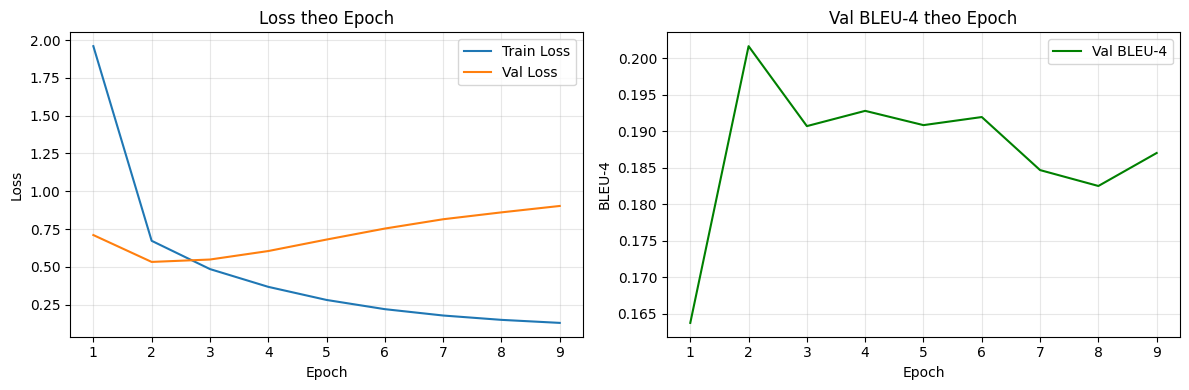

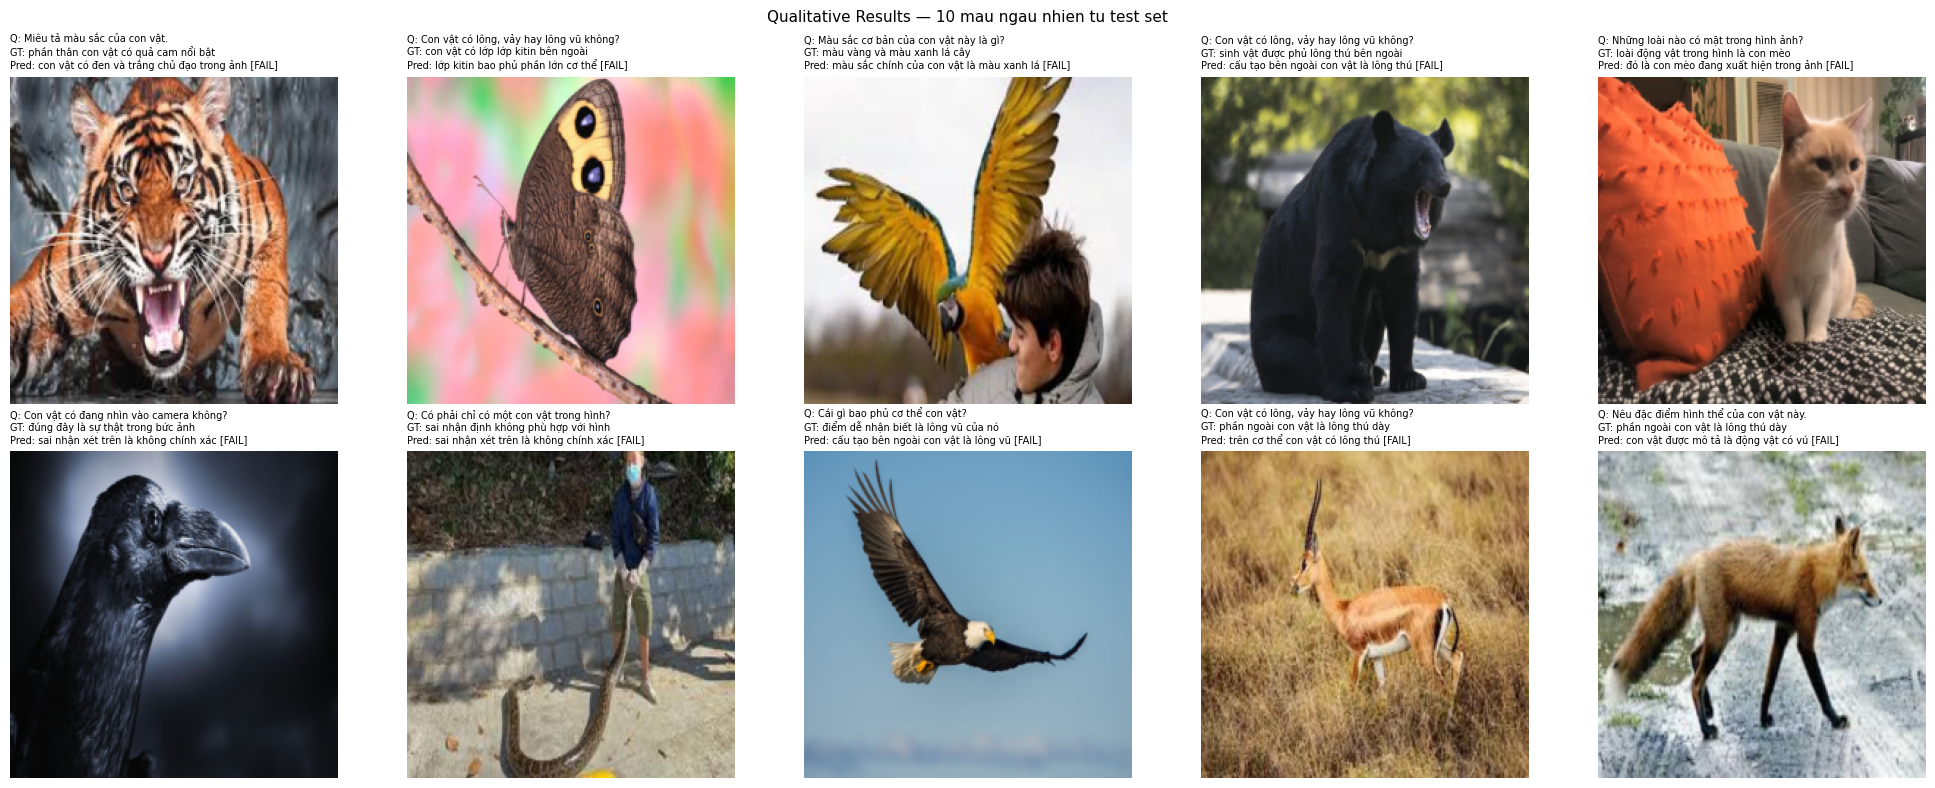

In [ ]:
# ---- Plot loss & BLEU-4 theo epoch ----
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_bleu4'], color='green', label='Val BLEU-4')
axes[1].set_title('Val BLEU-4 theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BLEU-4')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG['ckpt_dir'], 'training_curves_a1.png'), dpi=150)
plt.show()

# ---- Qualitative results: 10 mau ngau nhien tu test set ----
model.eval()
DENORM = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std =[1 / 0.229,      1 / 0.224,      1 / 0.225]
)

def shorten(text, max_chars=60):
    return text if len(text) <= max_chars else text[:max_chars - 1] + '…'

sample_indices = random.sample(range(len(test_ds)), 10)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax_idx, ds_idx in enumerate(sample_indices):
    img_t, q_ids, q_mask, ans_ids = test_ds[ds_idx]

    with torch.no_grad():
        pred_seq = model(
            img_t.unsqueeze(0).to(DEVICE),
            q_ids.unsqueeze(0).to(DEVICE),
            q_mask.unsqueeze(0).to(DEVICE)
        )[0]

    gt_str = ' '.join(ids_to_tokens(ans_ids[1:]))
    pr_str = ' '.join(ids_to_tokens(pred_seq))

    # Hien thi anh
    img_show = DENORM(img_t).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[ax_idx].imshow(img_show)
    axes[ax_idx].axis('off')

    question = str(test_df.iloc[ds_idx]['question'])
    match    = '[OK]' if gt_str.strip() == pr_str.strip() else '[FAIL]'

    axes[ax_idx].set_title(
        f"Q: {shorten(question)}\n"
        f"GT: {gt_str}\n"
        f"Pred: {pr_str} {match}",
        fontsize=7, loc='left'
    )

plt.suptitle('Qualitative Results — 10 mau ngau nhien tu test set', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CFG['ckpt_dir'], 'qualitative_results_a1.png'), dpi=150)
plt.show()

## Cell 9 — Gradio Demo

In [ ]:
!pip install -q gradio

import gradio as gr

# Dat model o eval mode
model.eval()

@torch.no_grad()
def vqa_predict(image, question):
    if image is None or not str(question).strip():
        return "Vui long cung cap ca anh va cau hoi."

    # Chuan hoa anh dau vao
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    image = image.convert('RGB')

    # Anh
    img_tensor = IMG_TRANSFORM(image).unsqueeze(0).to(DEVICE)

    # Tach tu va tokenize cau hoi
    question_seg = segment_vi(str(question))
    enc = PHOBERT_TOKENIZER(
        question_seg,
        max_length=CFG['q_max_len'],
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    q_ids  = enc['input_ids'].to(DEVICE)
    q_mask = enc['attention_mask'].to(DEVICE)

    # Inference
    pred_seq = model(img_tensor, q_ids, q_mask)[0]
    answer   = ' '.join(ids_to_tokens(pred_seq))
    return answer if answer else "(mo hinh khong sinh duoc cau tra loi)"


# Tao vi du demo tu test set
def _build_examples(n=3):
    examples = []
    for ds_idx in random.sample(range(len(test_ds)), n):
        row = test_df.iloc[ds_idx]
        img_path = test_ds.resolve_image_path(row)
        examples.append([img_path, str(row['question'])])
    return examples

demo = gr.Interface(
    fn=vqa_predict,
    inputs=[
        gr.Image(type='pil', label='Anh dong vat'),
        gr.Textbox(label='Cau hoi (tieng Viet)',
                   placeholder='VD: Con vat nay co mau gi?')
    ],
    outputs=gr.Textbox(label='Cau tra loi du doan'),
    title='VQA Demo - ViT + PhoBERT + Co-attention + LSTM',
    description=('Tai len anh dong vat va dat cau hoi tieng Viet. '
                 'Mo hinh sinh cau tra loi tu vung tu da hoc tren tap train.'),
    examples=_build_examples(3),
    allow_flagging='never'
)

demo.launch(share=True, debug=False)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c125c00452a8b4c218.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
